# AirNow NO₂ — Exploratory Data Analysis

This notebook walks through the AirNow hourly NO₂ dataset, explores missing data,
visualises site locations and time-series patterns, and verifies that both the
Transformer and Mamba models produce correct output shapes before training.

In [1]:
import sys, os
from pathlib import Path

# Resolve project root (works whether cwd is notebooks/ or the project root)
_here = Path(os.getcwd()).resolve()
ROOT = _here.parent if _here.name == "notebooks" else _here
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

DATA_DIR  = '/mnt/data3/AirNow'
PLOTS_DIR = ROOT / 'plots'
PLOTS_DIR.mkdir(exist_ok=True)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
print(f"ROOT      : {ROOT}")
print(f"PLOTS_DIR : {PLOTS_DIR}")
print(f"Python    : {sys.executable}")


ROOT      : /mnt/data3/isybelle1118/NO2 Forecasting
PLOTS_DIR : /mnt/data3/isybelle1118/NO2 Forecasting/plots
Python    : /mnt/data2/miniforge3/envs/cartopy/bin/python


## 1. Load all AirNow files

In [2]:
from data.load_airnow import load_all, site_meta

df   = load_all(DATA_DIR)
meta = site_meta(DATA_DIR)

print(f"Shape  : {df.shape}   ({df.shape[0]} hours × {df.shape[1]} sites)")
print(f"Range  : {df.index[0]}  →  {df.index[-1]}")
print(f"Missing: {df.isna().mean().mean()*100:.1f}% overall")
print(f"\nSite metadata ({len(meta)} sites):")
meta.head()

Shape  : (10992, 197)   (10992 hours × 197 sites)
Range  : 2023-07-01 00:00:00  →  2024-09-30 23:00:00
Missing: 13.7% overall

Site metadata (182 sites):


,lat,lon,name,agency
site,,,,
000081001,50.285831,-107.816887,SWIFT CURRENT,Saskatchewan Environment
000100110,49.279400,-122.971100,Kensington Park,Metro Vancouver
000100119,49.215279,-122.985558,Burnaby South,Metro Vancouver
000100125,49.158329,-122.901672,North Delta,Metro Vancouver
000100127,49.132778,-122.694168,Surrey East,Metro Vancouver


## 2. Missing data heatmap

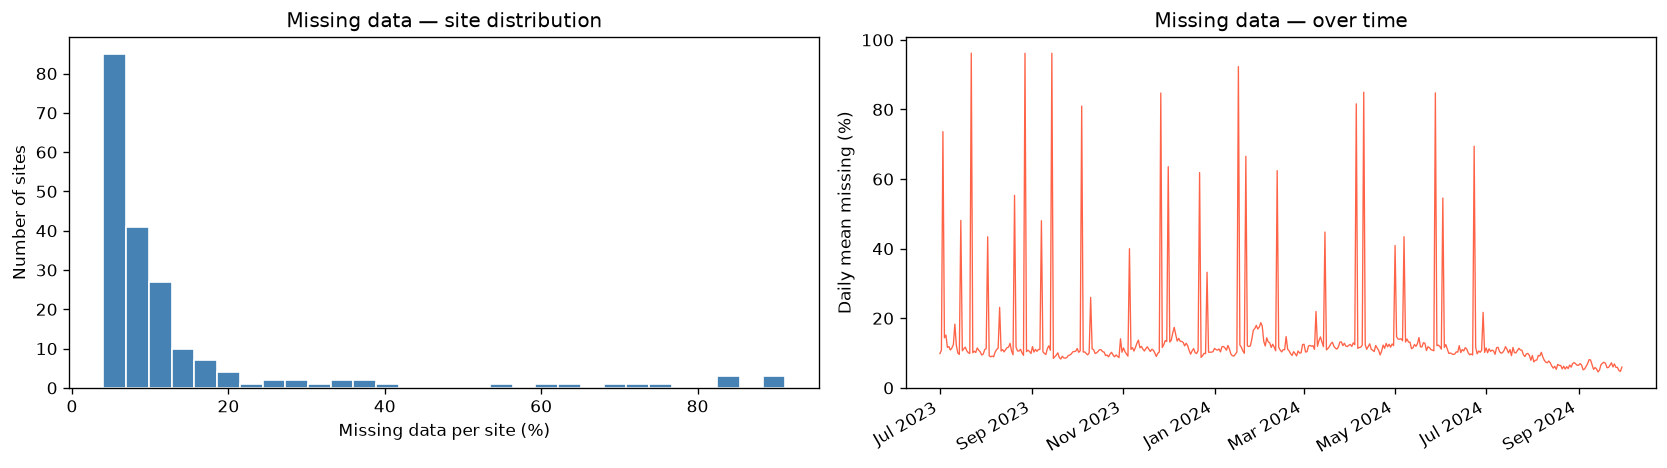

In [3]:
missing_by_site = df.isna().mean() * 100
missing_by_day  = df.isna().resample('D').mean().mean(axis=1) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(missing_by_site, bins=30, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Missing data per site (%)')
axes[0].set_ylabel('Number of sites')
axes[0].set_title('Missing data — site distribution')

axes[1].plot(missing_by_day.index, missing_by_day.values, color='tomato', lw=0.8)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')
axes[1].set_ylabel('Daily mean missing (%)')
axes[1].set_title('Missing data — over time')

plt.tight_layout()
plt.show()

## 3. Site map

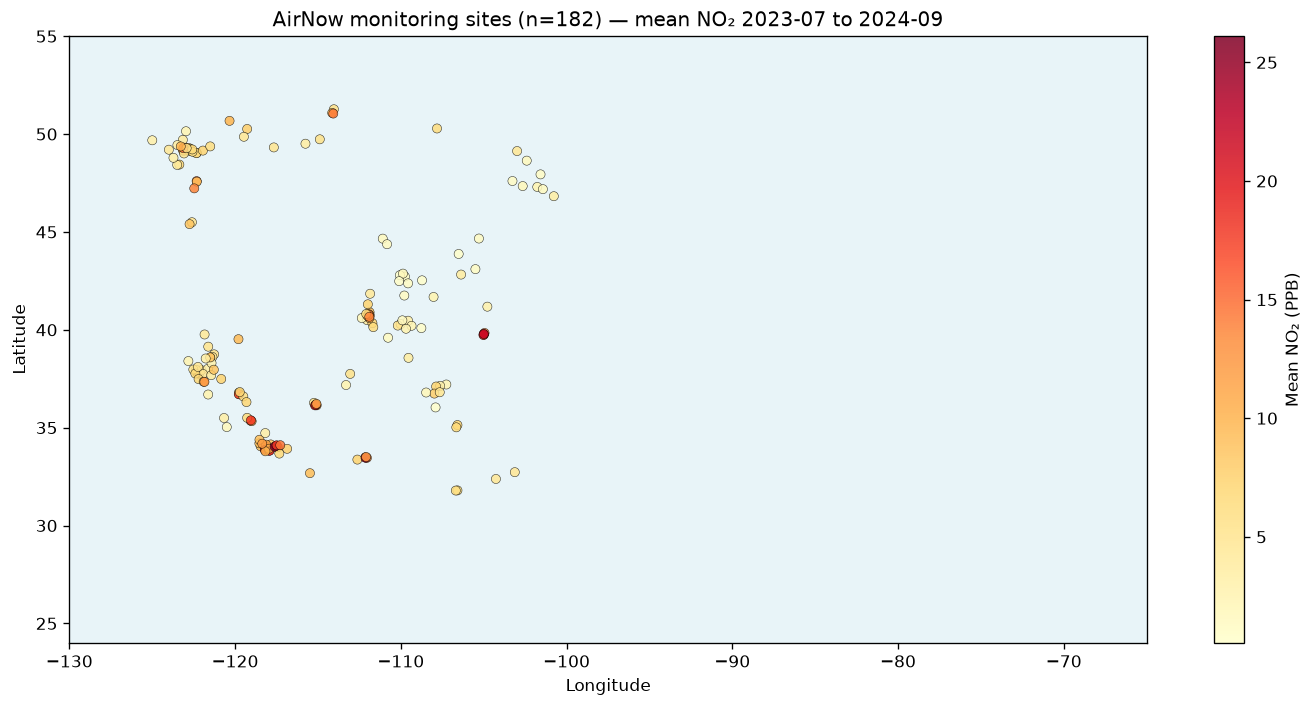

In [4]:
# Only sites that appear in both meta and df
common = meta.index.intersection(df.columns)
meta_c = meta.loc[common]
mean_no2 = df[common].mean()

fig, ax = plt.subplots(figsize=(12, 6))
sc = ax.scatter(
    meta_c['lon'], meta_c['lat'],
    c=mean_no2.loc[meta_c.index], cmap='YlOrRd',
    s=30, alpha=0.85, edgecolors='k', linewidths=0.3
)
plt.colorbar(sc, ax=ax, label='Mean NO₂ (PPB)')
ax.set_xlim(-130, -65)
ax.set_ylim(24, 55)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'AirNow monitoring sites (n={len(meta_c)}) — mean NO₂ 2023-07 to 2024-09')
ax.set_facecolor('#e8f4f8')
plt.tight_layout()
plt.show()

## 4. NO₂ time series — a few representative sites

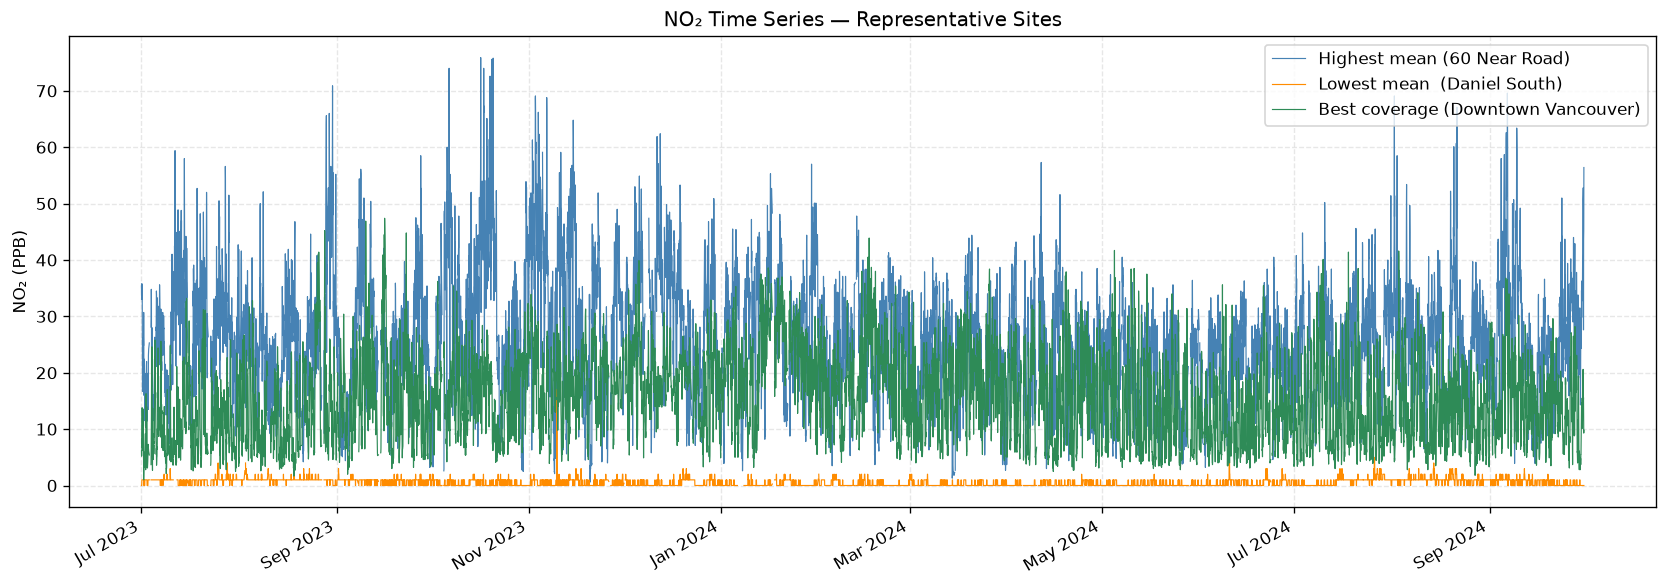

In [5]:

# Pick 3 sites: highest mean, lowest mean, best coverage
coverage = df.notna().mean()
mean_no2 = df.mean()

site_high = mean_no2.idxmax()
site_low  = mean_no2[coverage > 0.5].idxmin()
site_best = coverage.idxmax()

showcase = {
    f'Highest mean ({meta.loc[site_high, "name"] if site_high in meta.index else site_high})': (site_high, 'steelblue'),
    f'Lowest mean  ({meta.loc[site_low,  "name"] if site_low  in meta.index else site_low})':  (site_low,  'darkorange'),
    f'Best coverage ({meta.loc[site_best, "name"] if site_best in meta.index else site_best})': (site_best, 'seagreen'),
}

fig, ax = plt.subplots(figsize=(14, 5))

for label, (site, color) in showcase.items():
    ts = df[site].resample('h').mean()
    # Interpolate over short gaps (≤6 hours) so lines stay continuous
    ts_interp = ts.interpolate(method='time', limit=6)
    ax.plot(ts_interp.index, ts_interp.values, lw=0.7, color=color, label=label)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.set_ylabel('NO₂ (PPB)')
ax.set_title('NO₂ Time Series — Representative Sites')
ax.legend(loc='upper right')
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Diurnal cycle (average NO₂ by hour-of-day)

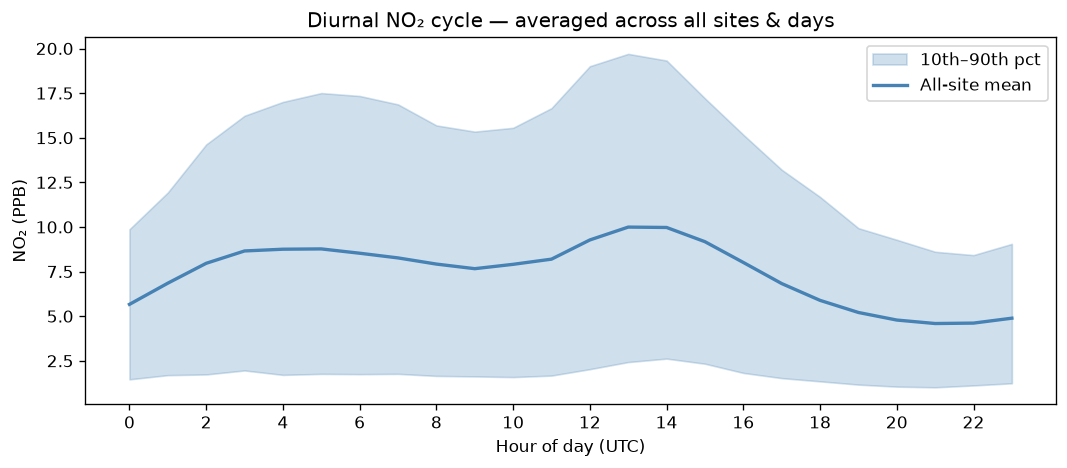

In [6]:
diurnal = df.groupby(df.index.hour).mean()   # (24, n_sites)
diurnal_mean = diurnal.mean(axis=1)
diurnal_p10  = diurnal.quantile(0.10, axis=1)
diurnal_p90  = diurnal.quantile(0.90, axis=1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.fill_between(diurnal_mean.index, diurnal_p10, diurnal_p90,
                alpha=0.25, color='steelblue', label='10th–90th pct')
ax.plot(diurnal_mean.index, diurnal_mean.values, color='steelblue',
        lw=2, label='All-site mean')
ax.set_xlabel('Hour of day (UTC)')
ax.set_ylabel('NO₂ (PPB)')
ax.set_title('Diurnal NO₂ cycle — averaged across all sites & days')
ax.set_xticks(range(0, 24, 2))
ax.legend()
plt.tight_layout()
plt.show()

## 6. Monthly seasonal pattern

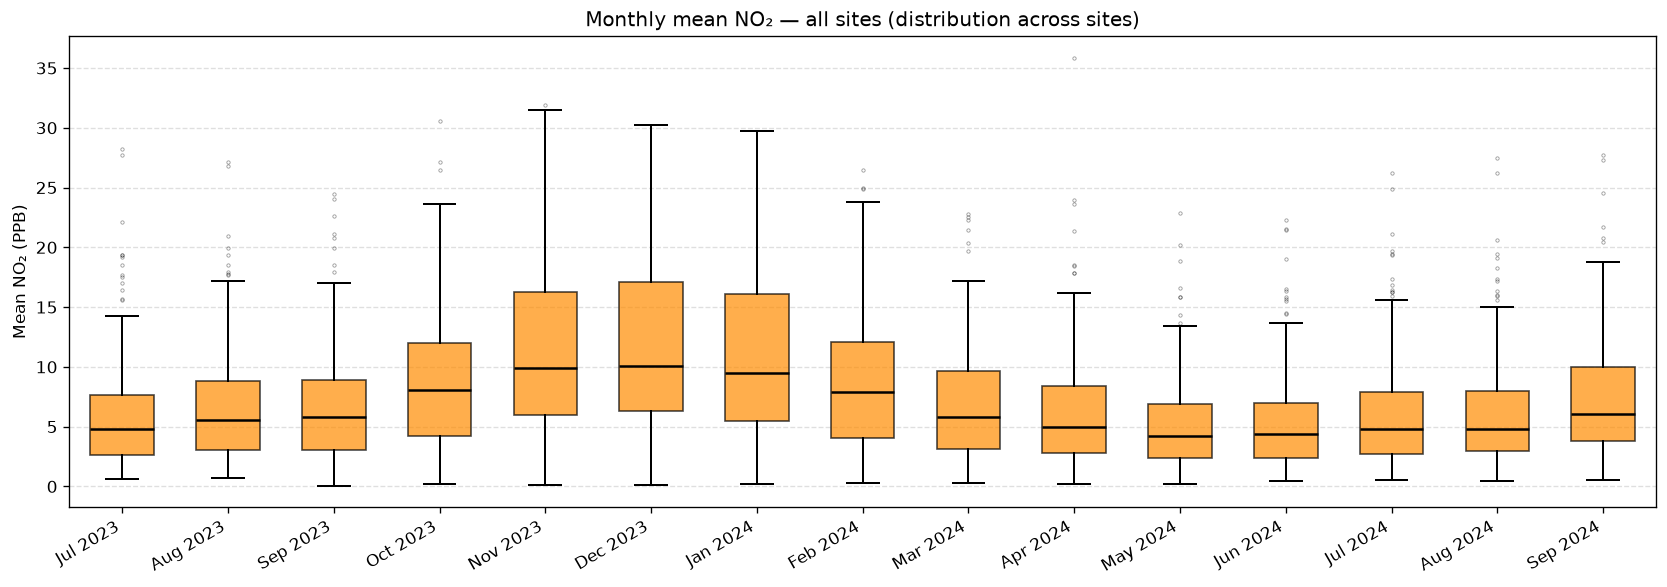

Saved monthly_boxplot.png


In [7]:
monthly_per_site = df.resample('ME').mean()   # shape: (n_months, n_sites)

positions = list(range(len(monthly_per_site)))
data      = [monthly_per_site.iloc[i].dropna().values for i in positions]
labels    = [d.strftime('%b %Y') for d in monthly_per_site.index]

fig, ax = plt.subplots(figsize=(14, 5))
bp = ax.boxplot(
    data,
    positions=positions,
    widths=0.6,
    patch_artist=True,
    boxprops=dict(facecolor='darkorange', alpha=0.7),
    medianprops=dict(color='black', lw=1.5),
    whiskerprops=dict(lw=1.2),
    capprops=dict(lw=1.2),
    flierprops=dict(marker='o', markersize=2, alpha=0.4, markeredgewidth=0.5),
)
ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel('Mean NO₂ (PPB)')
ax.set_title('Monthly mean NO₂ — all sites (distribution across sites)')
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'monthly_boxplot.png', dpi=150)
plt.show()
print('Saved monthly_boxplot.png')


## 7. Build sequences for training

In [8]:
from data.load_airnow import load_sequences

SEQ_LEN  = 24    # look-back: 24 hours
PRED_LEN = 6     # forecast:   6 hours ahead

X, y, timestamps, sites = load_sequences(
    DATA_DIR, seq_len=SEQ_LEN, pred_len=PRED_LEN,
    normalize=True, fill_nan=0
)
print(f"X : {X.shape}   (windows × seq_len × n_sites)")
print(f"y : {y.shape}   (windows × pred_len × n_sites)")
print(f"Sites in sequences: {len(sites)}")

X : (10963, 24, 197)   (windows × seq_len × n_sites)
y : (10963, 6, 197)   (windows × pred_len × n_sites)
Sites in sequences: 197


In [9]:
# Chronological train / val / test split (no shuffling — time series!)
n       = len(X)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

X_train, y_train = X[:n_train],              y[:n_train]
X_val,   y_val   = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
X_test,  y_test  = X[n_train+n_val:],        y[n_train+n_val:]

print(f"Train : {X_train.shape[0]:>6} windows  |  {timestamps[0]} → {timestamps[n_train-1]}")
print(f"Val   : {X_val.shape[0]:>6} windows  |  {timestamps[n_train]} → {timestamps[n_train+n_val-1]}")
print(f"Test  : {X_test.shape[0]:>6} windows  |  {timestamps[n_train+n_val]} → {timestamps[-1]}")

Train :   7674 windows  |  2023-07-01 00:00:00 → 2024-05-15 17:00:00
Val   :   1644 windows  |  2024-05-15 18:00:00 → 2024-07-23 05:00:00
Test  :   1645 windows  |  2024-07-23 06:00:00 → 2024-09-29 18:00:00


## 8. Verify model forward passes

In [10]:
import torch
from models.transformer_no2 import NO2Transformer
from models.mamba_no2 import NO2Mamba

N_SITES  = X.shape[2]
DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device : {DEVICE}")
print(f"Batch  : n_sites={N_SITES}, seq_len={SEQ_LEN}, pred_len={PRED_LEN}")

batch = torch.tensor(X[:8], dtype=torch.float32).to(DEVICE)

# Transformer
tf_model = NO2Transformer(n_sites=N_SITES, seq_len=SEQ_LEN, pred_len=PRED_LEN).to(DEVICE)
tf_out   = tf_model(batch)
print(f"\nTransformer output : {tuple(tf_out.shape)}  ✓" if tf_out.shape == (8, PRED_LEN, N_SITES)
      else f"Transformer output : {tuple(tf_out.shape)}  — unexpected!")
print(f"  Parameters       : {sum(p.numel() for p in tf_model.parameters()):,}")

# Mamba
mb_model = NO2Mamba(n_sites=N_SITES, seq_len=SEQ_LEN, pred_len=PRED_LEN).to(DEVICE)
mb_out   = mb_model(batch)
print(f"\nMamba output       : {tuple(mb_out.shape)}  ✓" if mb_out.shape == (8, PRED_LEN, N_SITES)
      else f"Mamba output       : {tuple(mb_out.shape)}  — unexpected!")
print(f"  Parameters       : {sum(p.numel() for p in mb_model.parameters()):,}")

Device : cuda
Batch  : n_sites=197, seq_len=24, pred_len=6

Transformer output : (8, 6, 197)  ✓
  Parameters       : 3,922,590

Mamba output       : (8, 6, 197)  ✓
  Parameters       : 4,020,126


## 9. Quick training smoke-test (5 epochs)

Trains both models for 5 epochs on a small subset — verifies the training loop works end-to-end before running a full training run.

In [11]:
from models.transformer_no2 import train, evaluate

# Use a small subset for the smoke-test
Xs = X_train[:2000];  ys = y_train[:2000]
Xv = X_val[:500];     yv = y_val[:500]

print("=== Transformer (smoke-test) ===")
tf_model = NO2Transformer(n_sites=N_SITES, seq_len=SEQ_LEN, pred_len=PRED_LEN)
train(tf_model, Xs, ys, Xv, yv, epochs=5, batch_size=64, lr=1e-3)

print("\n=== Mamba (smoke-test) ===")
mb_model = NO2Mamba(n_sites=N_SITES, seq_len=SEQ_LEN, pred_len=PRED_LEN)
train(mb_model, Xs, ys, Xv, yv, epochs=5, batch_size=64, lr=1e-3)

=== Transformer (smoke-test) ===
Epoch   1 | train MSE=0.8097 val MSE=1.5068 MAE=0.7732
Epoch   2 | train MSE=0.4628 val MSE=1.2581 MAE=0.6268
Epoch   3 | train MSE=0.3860 val MSE=1.3204 MAE=0.6653
Epoch   4 | train MSE=0.3346 val MSE=1.2752 MAE=0.6233
Epoch   5 | train MSE=0.2984 val MSE=1.3633 MAE=0.6750

=== Mamba (smoke-test) ===
Epoch   1 | train MSE=0.5482 val MSE=1.5745 MAE=0.8114
Epoch   2 | train MSE=0.3315 val MSE=1.6470 MAE=0.8447
Epoch   3 | train MSE=0.2636 val MSE=1.6202 MAE=0.8179
Epoch   4 | train MSE=0.2237 val MSE=1.6294 MAE=0.8195
Epoch   5 | train MSE=0.1954 val MSE=1.6177 MAE=0.8062


[{'epoch': 1,
  'train_mse': 0.5482437195777893,
  'val_mse': 1.5745187997817993,
  'val_mae': 0.8114286065101624},
 {'epoch': 2,
  'train_mse': 0.3315207569599152,
  'val_mse': 1.6470253467559814,
  'val_mae': 0.8447209596633911},
 {'epoch': 3,
  'train_mse': 0.26355147957801817,
  'val_mse': 1.6201852560043335,
  'val_mae': 0.8178545832633972},
 {'epoch': 4,
  'train_mse': 0.22374085330963134,
  'val_mse': 1.6294264793395996,
  'val_mae': 0.819502055644989},
 {'epoch': 5,
  'train_mse': 0.19540540194511413,
  'val_mse': 1.6176607608795166,
  'val_mae': 0.80624920129776}]

In [12]:
# Evaluate smoke-test models on the test slice
Xt = X_test[:500];  yt = y_test[:500]

tf_mse, tf_mae = evaluate(tf_model, Xt, yt)
mb_mse, mb_mae = evaluate(mb_model, Xt, yt)

print(f"{'Model':<15} {'MSE':>10} {'MAE':>10}")
print("-" * 37)
print(f"{'Transformer':<15} {tf_mse:>10.4f} {tf_mae:>10.4f}")
print(f"{'Mamba':<15} {mb_mse:>10.4f} {mb_mae:>10.4f}")
print("\n(5-epoch smoke-test only — run full training for meaningful comparison)")

Model                  MSE        MAE
-------------------------------------
Transformer         2.0495     0.7179
Mamba               2.7346     1.0127

(5-epoch smoke-test only — run full training for meaningful comparison)


## 10. Daily mean NO₂ time series

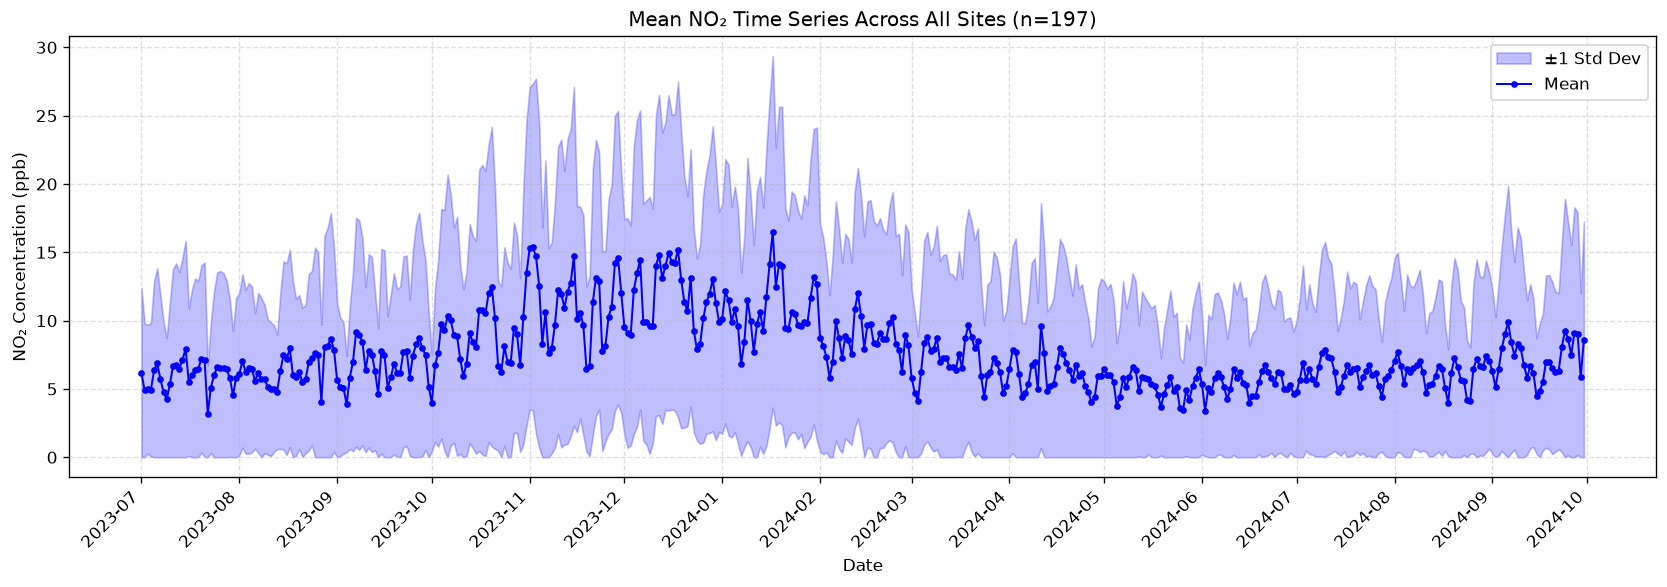

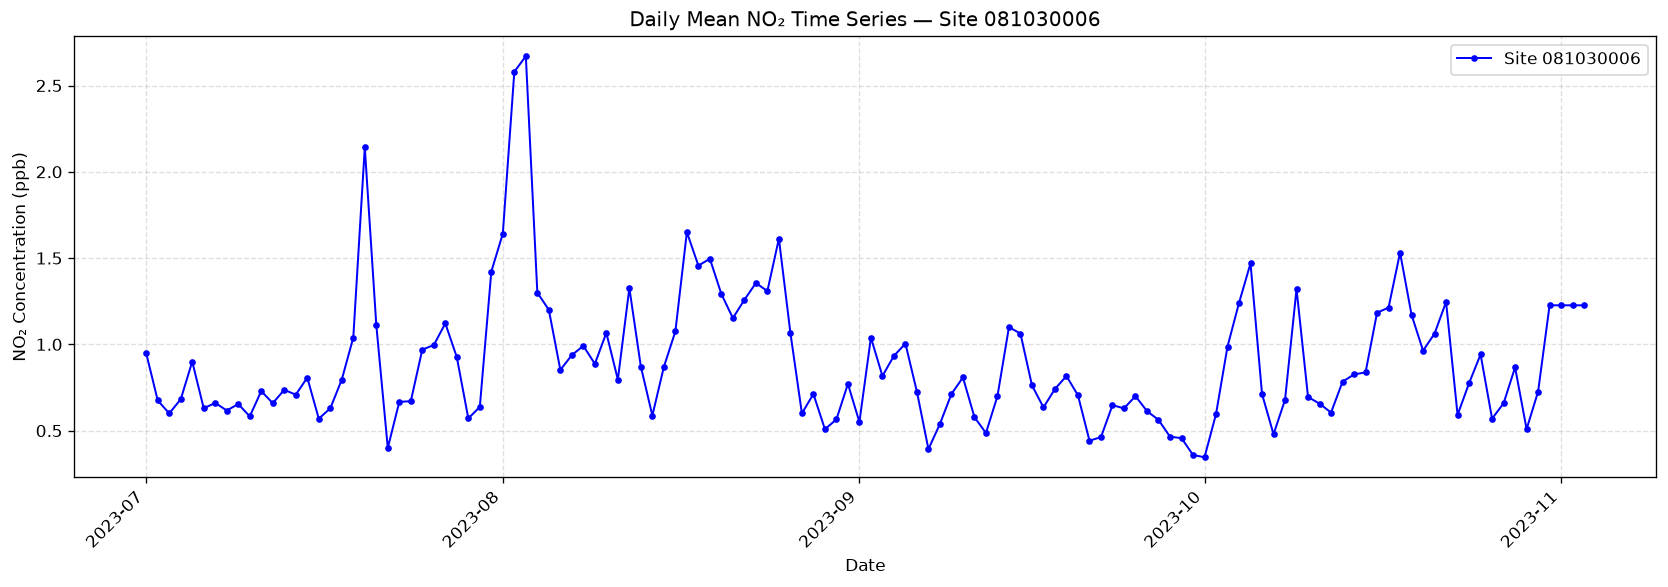

In [13]:

SITE = '081030006'

daily_site = df[SITE].resample('D').mean()
daily_all  = df.mean(axis=1).resample('D').mean()
daily_std  = df.std(axis=1).resample('D').mean()

# Clip lower band at 0 — NO₂ cannot be negative
lower_band = (daily_all - daily_std).clip(lower=0)
upper_band =  daily_all + daily_std

# Interpolate over short gaps (≤3 days)
daily_all_interp  = daily_all.interpolate(method='time', limit=3)
daily_site_interp = daily_site.interpolate(method='time', limit=3)

# ── All-sites plot ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(daily_all.index, lower_band, upper_band,
                color='blue', alpha=0.25, label='±1 Std Dev')
ax.plot(daily_all_interp.index, daily_all_interp.values,
        color='blue', lw=1.2, marker='o', markersize=3, label='Mean')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.set_xlabel('Date')
ax.set_ylabel('NO₂ Concentration (ppb)')
ax.set_title('Mean NO₂ Time Series Across All Sites (n=197)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ── Site-specific plot ────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(14, 5))

ax2.plot(daily_site_interp.index, daily_site_interp.values,
         color='blue', lw=1.2, marker='o', markersize=3, label=f'Site {SITE}')

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax2.set_xlabel('Date')
ax2.set_ylabel('NO₂ Concentration (ppb)')
ax2.set_title(f'Daily Mean NO₂ Time Series — Site {SITE}')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


## 11. Spatial interpolation map — continuous NO₂ surface from site observations

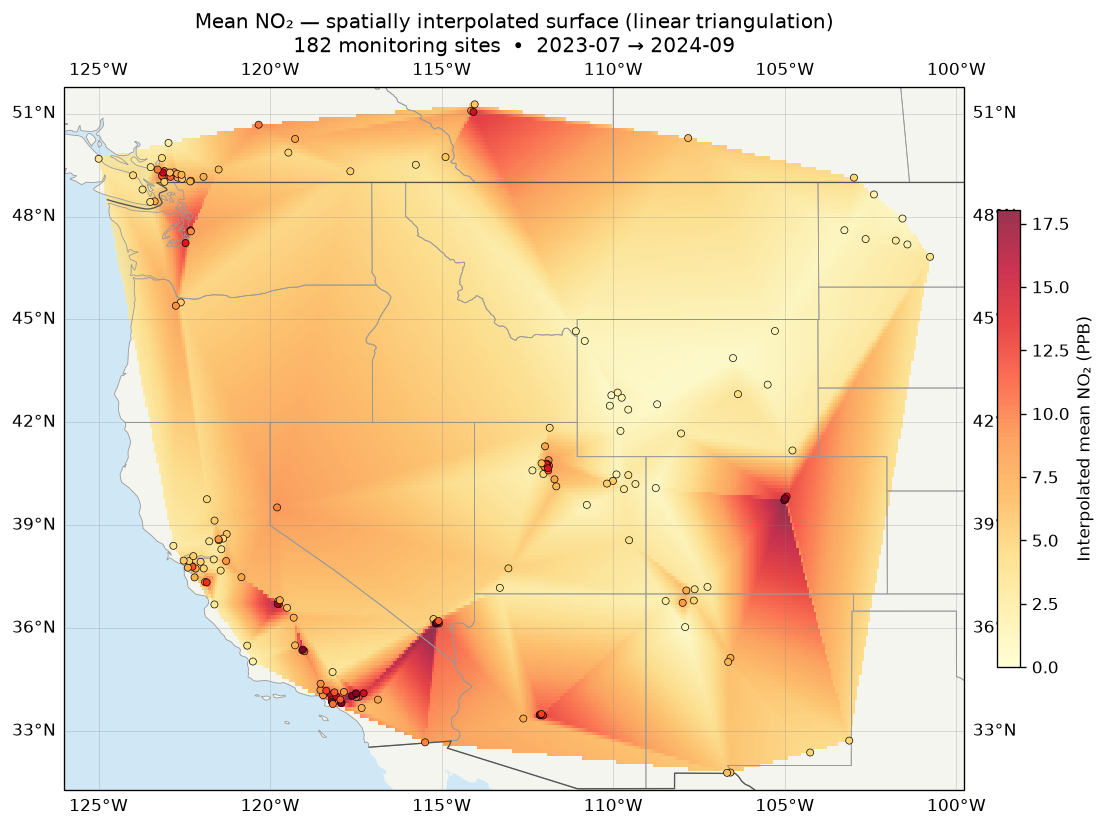

Saved spatial_interp_no2.png


In [14]:
from scipy.interpolate import griddata
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Build a regular lat/lon grid over the monitoring network extent
lat_pts  = np.linspace(meta_c['lat'].min() - 0.5, meta_c['lat'].max() + 0.5, 200)
lon_pts  = np.linspace(meta_c['lon'].min() - 0.5, meta_c['lon'].max() + 0.5, 400)
lon_grid, lat_grid = np.meshgrid(lon_pts, lat_pts)

# Linear triangulation interpolation from 197 point observations to the grid
pts      = np.column_stack([meta_c['lon'].values, meta_c['lat'].values])
vals     = mean_no2.loc[meta_c.index].values
no2_grid = griddata(pts, vals, (lon_grid, lat_grid), method='linear')

vmax = float(np.nanpercentile(vals, 95))

fig = plt.figure(figsize=(14, 7))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent(
    [meta_c['lon'].min() - 1, meta_c['lon'].max() + 1,
     meta_c['lat'].min() - 0.5, meta_c['lat'].max() + 0.5],
    crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND,    facecolor='#f5f5f0')
ax.add_feature(cfeature.OCEAN,   facecolor='#d0e8f5')
ax.add_feature(cfeature.STATES,  linewidth=0.5, edgecolor='#999999')
ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor='#555555')

pcm = ax.pcolormesh(lon_grid, lat_grid, no2_grid,
                    cmap='YlOrRd', vmin=0, vmax=vmax, alpha=0.8,
                    transform=ccrs.PlateCarree())
plt.colorbar(pcm, ax=ax, label='Interpolated mean NO₂ (PPB)', shrink=0.65, pad=0.02)

# Overlay actual site dots for reference
ax.scatter(meta_c['lon'], meta_c['lat'],
           c=vals, cmap='YlOrRd', vmin=0, vmax=vmax,
           s=18, edgecolors='k', linewidths=0.4, zorder=5,
           transform=ccrs.PlateCarree())

ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5,
             x_inline=False, y_inline=False)
ax.set_title(
    f'Mean NO₂ — spatially interpolated surface (linear triangulation)\n'
    f'{len(meta_c)} monitoring sites  •  2023-07 → 2024-09')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'spatial_interp_no2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved spatial_interp_no2.png')
